# Reinforcement Learning for the Game of Nim

This notebook implements and compares two reinforcement learning approaches:

1. Tabular Q-Learning
2. Linear Reward-Inaction (LR-I) Learning Automaton

Both agents are trained on the game of Nim and evaluated against random and optimal opponents.

In [1]:
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt

# Environment

The game of Nim is represented using three piles with initial state (3,4,5).

A player selects a pile and removes one or more stones.

The player taking the final stone wins.

The environment handles state transitions, legal actions and terminal-state detection.

In [2]:
class NimGame:
    def __init__(self, piles=(3, 4, 5)):
        self.initial = tuple(piles)

    def reset(self):
        return self.initial

    def legal_actions(self, state):
        # every (pile i, take t) where 1 <= t <= pile size
        return [(i, t) for i, c in enumerate(state) for t in range(1, c + 1)]

    def step(self, state, action):
        i, take = action
        s = list(state)
        s[i] -= take
        s = tuple(s)
        done = all(x == 0 for x in s)   # last object taken -> mover wins
        return s, done

# Opponent Policies

Two opponent strategies are implemented.

Random Opponent:
- Chooses a legal move uniformly at random.

Optimal Opponent:
- Uses the Nim-sum (XOR) strategy.
- Provides a mathematically optimal benchmark.

In [3]:
def nim_sum(state):
    r = 0
    for x in state:
        r ^= x
    return r

def optimal_action(state, env):
    ns = nim_sum(state)
    if ns != 0:
        for i, c in enumerate(state):
            target = c ^ ns
            if target < c:
                return (i, c - target)
    for i, c in enumerate(state):
        if c > 0:
            return (i, 1)

def random_action(state, env):
    return random.choice(env.legal_actions(state))

# Q-Learning Agent

The Q-Learning agent stores state-action values in a Q-table.

Actions are selected using an epsilon-greedy policy.

Learning is performed using the Bellman update rule with:

- alpha = 0.3
- gamma = 0.95
- epsilon decay

In [4]:
class QAgent:
    def __init__(self, alpha=0.3, gamma=0.95, eps=1.0, eps_min=0.02, eps_decay=0.9998):
        self.Q = defaultdict(float)
        self.alpha, self.gamma = alpha, gamma
        self.eps, self.eps_min, self.eps_decay = eps, eps_min, eps_decay

    def select_action(self, state, actions, greedy=False):
        if (not greedy) and random.random() < self.eps:
            return random.choice(actions)                 # explore
        q_vals = [self.Q[(state, a)] for a in actions]
        return actions[int(np.argmax(q_vals))]            # exploit

    def update(self, s, a, r, s2, next_actions, done):
        if done:
            target = r
        else:
            target = r + self.gamma * max(self.Q[(s2, a2)] for a2 in next_actions)
        self.Q[(s, a)] += self.alpha * (target - self.Q[(s, a)])

    def decay(self):
        self.eps = max(self.eps_min, self.eps * self.eps_decay)

# LR-I Learning Automaton

The LR-I automaton maintains a probability distribution over actions.

Winning actions are reinforced.

Losing actions do not trigger updates, following the reward-inaction principle.

In [5]:
class LRIAgent:
    def __init__(self, a=0.05):
        self.a = a              # reward parameter
        self.auto = {}          # state -> {'actions': [...], 'p': prob vector}
        self.trace = []         # (state, chosen_index) picked this episode

    def _ensure(self, state, actions):
        if state not in self.auto:
            n = len(actions)
            self.auto[state] = {'actions': actions, 'p': np.ones(n) / n}

    def select_action(self, state, actions, greedy=False):
        self._ensure(state, actions)
        p = self.auto[state]['p']
        idx = int(np.argmax(p)) if greedy else int(np.random.choice(len(p), p=p))
        self.trace.append((state, idx))
        return self.auto[state]['actions'][idx]

    def start_episode(self):
        self.trace = []

    def update_episode(self, won):
        if not won:                       # LR-I: inaction on penalty
            return
        for state, idx in self.trace:     # reward every action taken in the won game
            p = self.auto[state]['p']
            new_p = (1 - self.a) * p
            new_p[idx] = p[idx] + self.a * (1 - p[idx])
            self.auto[state]['p'] = new_p

# Training and Evaluation Functions

The play() function runs a complete game between an agent and an opponent.

The evaluate() function estimates win rate over many games.

A mixed opponent is also provided, playing:
- 70% optimal moves
- 30% random moves

In [6]:
def play(agent, opponent, env, train=True, la=False):
    s = env.reset()
    if la and train:
        agent.start_episode()
    while True:
        a = agent.select_action(s, env.legal_actions(s), greedy=not train)
        s1, done = env.step(s, a)
        if done:                                   # agent took last -> win
            if train and not la: agent.update(s, a, 1, s1, [], True)
            if train and la:     agent.update_episode(True)
            return 1
        s2, done2 = env.step(s1, opponent(s1, env))
        if done2:                                  # opponent took last -> loss
            if train and not la: agent.update(s, a, -1, s2, [], True)
            if train and la:     agent.update_episode(False)
            return -1
        if train and not la:                       # non-terminal Q update
            agent.update(s, a, 0, s2, env.legal_actions(s2), False)
        s = s2

def evaluate(agent, opponent, env, n=2000, la=False):
    return sum(1 for _ in range(n) if play(agent, opponent, env, False, la) == 1) / n

def mixed(p):
    """Opponent that plays optimally with prob p, else randomly."""
    def f(state, env):
        return optimal_action(state, env) if random.random() < p else random_action(state, env)
    return f

# Training Procedure

Both agents are trained for 30,000 episodes.

Training uses a mixed opponent:
- 70% optimal
- 30% random

Rolling win rates are recorded every 300 episodes to track learning progress.

In [7]:
random.seed(42); np.random.seed(42)
env = NimGame((3, 4, 5))
opponent = mixed(0.7)
EPISODES, WINDOW = 30000, 300

q  = QAgent()
la = LRIAgent(a=0.05)

q_curve, la_curve = [], []
q_wins = la_wins = 0
for ep in range(1, EPISODES + 1):
    q_wins  += (play(q,  opponent, env, train=True)            == 1)
    la_wins += (play(la, opponent, env, train=True, la=True)   == 1)
    q.decay()
    if ep % WINDOW == 0:
        q_curve.append(q_wins / WINDOW)
        la_curve.append(la_wins / WINDOW)
        q_wins = la_wins = 0

print("Training done.")

Training done.


# Evaluation Results

After training, exploration is disabled.

The agents are evaluated against:

1. Random opponent
2. Optimal Nim-sum opponent

The learned first move is also compared against the mathematically optimal move.

In [8]:
results = {
    "Q vs random":   evaluate(q,  random_action,  env),
    "Q vs optimal":  evaluate(q,  optimal_action, env, 500),
    "LA vs random":  evaluate(la, random_action,  env, la=True),
    "LA vs optimal": evaluate(la, optimal_action, env, 500, la=True),
}
for k, v in results.items():
    print(f"{k:14s}: {v:.3f}")

start = (3, 4, 5)
print("\nQ-agent's first move :", q.select_action(start, env.legal_actions(start), greedy=True))
print("Optimal first move   :", optimal_action(start, env))

Q vs random   : 1.000
Q vs optimal  : 1.000
LA vs random  : 0.995
LA vs optimal : 0.000

Q-agent's first move : (0, 2)
Optimal first move   : (0, 2)


# Visualisation

The following plots show:

1. Learning curves during training.
2. Final win rates against different opponents.

These visualisations help compare convergence and overall performance.

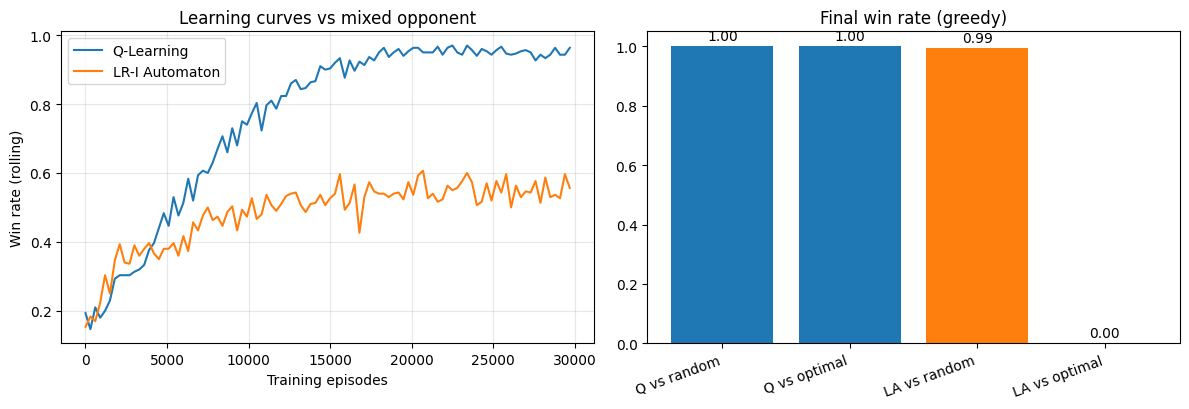

In [9]:
x = np.arange(len(q_curve)) * WINDOW
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].plot(x, q_curve,  label="Q-Learning")
ax[0].plot(x, la_curve, label="LR-I Automaton")
ax[0].set_xlabel("Training episodes"); ax[0].set_ylabel("Win rate (rolling)")
ax[0].set_title("Learning curves vs mixed opponent"); ax[0].legend(); ax[0].grid(alpha=.3)

labels = list(results); vals = [results[k] for k in labels]
ax[1].bar(range(4), vals, color=["#1f77b4","#1f77b4","#ff7f0e","#ff7f0e"])
ax[1].set_xticks(range(4)); ax[1].set_xticklabels(labels, rotation=20, ha="right")
ax[1].set_ylim(0, 1.05); ax[1].set_title("Final win rate (greedy)")
for i, v in enumerate(vals): ax[1].text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout(); plt.show()